In [ ]:
!pip install opencv-python

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving images.zip to images (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile('images.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

In [ ]:
IMG_SIZE = 64

data = []
labels = []

dataset_path = 'dataset/images'

for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)

    if not os.path.isdir(category_path):
        continue

    for img_name in os.listdir(category_path):
        try:
            img_path = os.path.join(category_path, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0

            data.append(img.flatten())
            labels.append(category)

        except:
            continue

X = np.array(data)
y = np.array(labels)

print("Loaded images:", len(X))

Loaded images: 309


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(rf, param_grid, cv=3, verbose=2, n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7258064516129032
              precision    recall  f1-score   support

   dalmatian       0.77      0.71      0.74        14
 dollar_bill       0.73      0.80      0.76        10
       pizza       0.57      0.40      0.47        10
 soccer_ball       0.67      0.73      0.70        11
   sunflower       0.79      0.88      0.83        17

    accuracy                           0.73        62
   macro avg       0.70      0.70      0.70        62
weighted avg       0.72      0.73      0.72        62



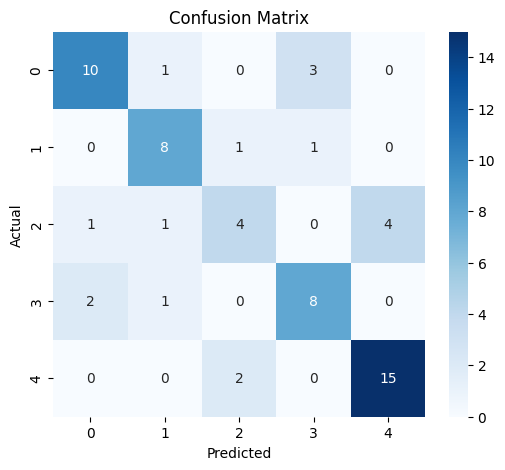

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

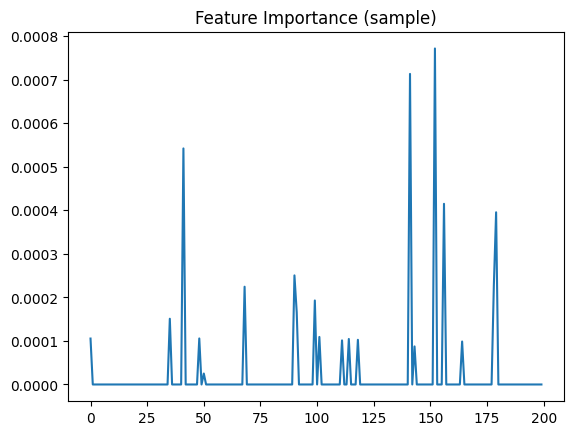

In [ ]:
importances = best_model.feature_importances_

plt.plot(importances[:200])
plt.title("Feature Importance (sample)")
plt.show()

In [ ]:
svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.7741935483870968


In [ ]:
import os

image_paths = []

for root, dirs, files in os.walk('dataset'):
    for file in files:
        if file.endswith('.jpg'):
            full_path = os.path.join(root, file)
            image_paths.append(full_path)

# show first 5 images
for path in image_paths[:5]:
    print(path)

dataset/images/pizza/image_0039.jpg
dataset/images/pizza/image_0032.jpg
dataset/images/pizza/image_0028.jpg
dataset/images/pizza/image_0042.jpg
dataset/images/pizza/image_0017.jpg


In [ ]:
for path in image_paths[:5]:
    result = predict_image(path)
    print(path, "→", result)

dataset/images/pizza/image_0039.jpg → pizza
dataset/images/pizza/image_0032.jpg → pizza
dataset/images/pizza/image_0028.jpg → pizza
dataset/images/pizza/image_0042.jpg → pizza
dataset/images/pizza/image_0017.jpg → pizza


In [ ]:
test_images = [
    "dataset/images/pizza/image_0039.jpg",
    "dataset/images/soccer_ball/image_0032.jpg",
    "dataset/images/dalmatian/image_0039.jpg",
    "dataset/images/dollar_bill/image_0039.jpg",
    "dataset/images/sunflower/image_0039.jpg"
]

for path in test_images:
    print(path, "→", predict_image(path))

dataset/images/pizza/image_0039.jpg → pizza
dataset/images/soccer_ball/image_0032.jpg → soccer_ball
dataset/images/dalmatian/image_0039.jpg → dalmatian
dataset/images/dollar_bill/image_0039.jpg → dollar_bill
dataset/images/sunflower/image_0039.jpg → sunflower
